In [1]:
from google.colab import files
uploaded = files.upload()

Saving bank.csv to bank (1).csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [6]:
df.shape

(11162, 17)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [8]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [11]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [12]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


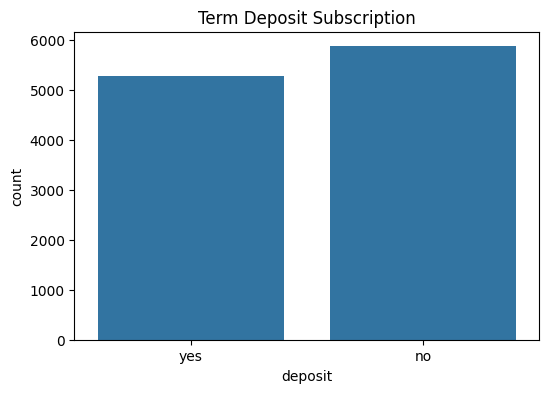

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df)
plt.title('Term Deposit Subscription')
plt.show()

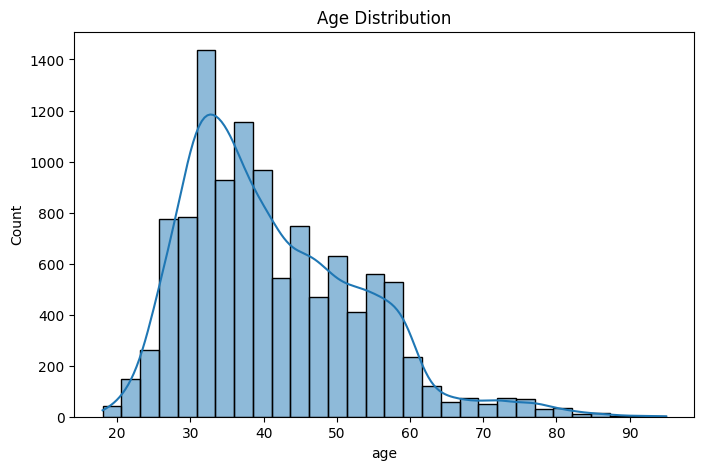

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

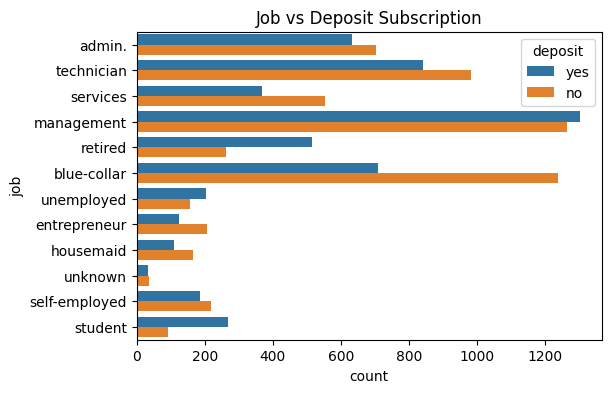

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(y='job', hue='deposit', data=df)
plt.title('Job vs Deposit Subscription')
plt.show()

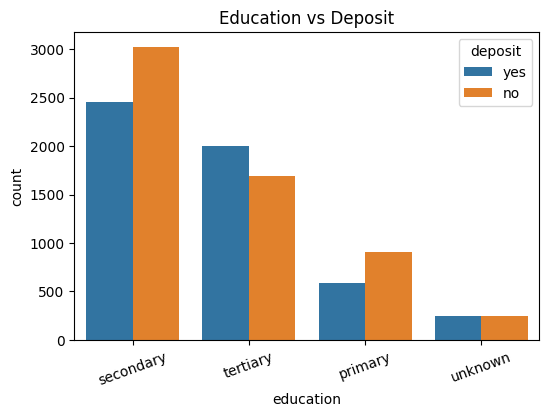

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='education', hue='deposit', data=df)
plt.title('Education vs Deposit')
plt.xticks(rotation=20)
plt.show()

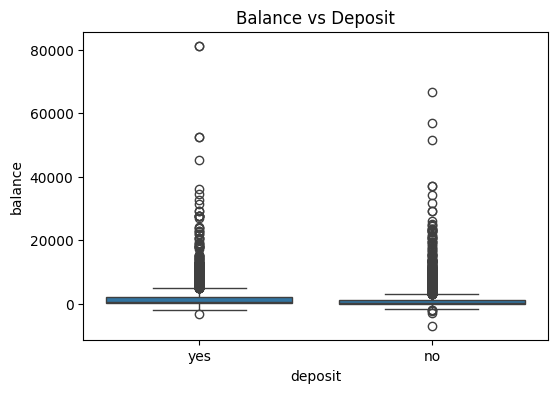

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='deposit', y='balance', data=df)
plt.title('Balance vs Deposit')
plt.show()

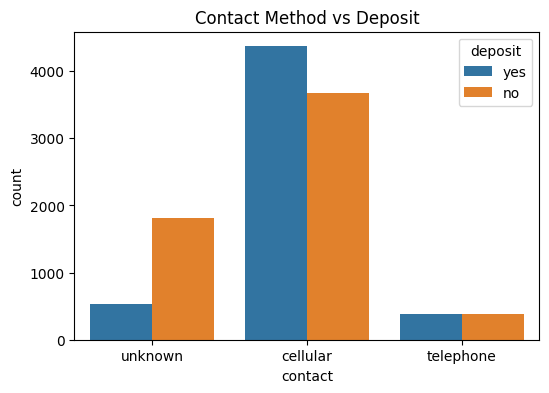

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='contact', hue='deposit', data=df)
plt.title('Contact Method vs Deposit')
plt.show()

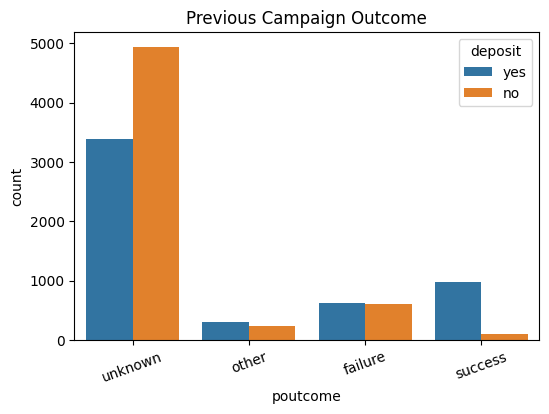

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='poutcome', hue='deposit', data=df)
plt.title('Previous Campaign Outcome')
plt.xticks(rotation=20)
plt.show()

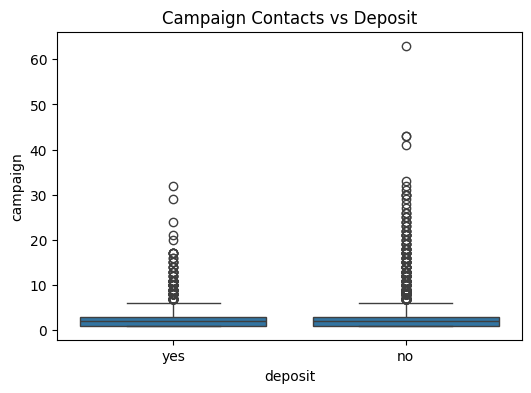

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x='deposit', y='campaign', data=df)
plt.title('Campaign Contacts vs Deposit')
plt.show()

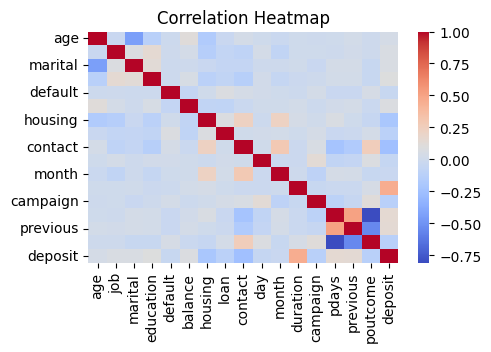

In [25]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object').columns:
  le = LabelEncoder()
  df_encoded[col]= le.fit_transform(df_encoded[col])
plt.figure(figsize=(5,3))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()